In [1]:
from google.colab import drive
import numpy as np


In [4]:
drive.mount("/content/drive", force_remount = True)

OUTPUT_DIR = "/content/drive/MyDrive/neurosynth/data/processed"

X = np.load(f"{OUTPUT_DIR}/X.npy")
y = np.load(f"{OUTPUT_DIR}/y.npy")
subject_ids = np.load(f"{OUTPUT_DIR}/subjects_ids.npy")


print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Left fist: {(y==0).sum()}, Right fist: {(y ==1).sum()}")

Mounted at /content/drive
X shape: (900, 64, 641)
y shape: (900,)
Left fist: 455, Right fist: 445


In [5]:
import os


ARTIFACT_DIR = "/content/drive/MyDrive/neurosynth/artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok= True)
print("Artifact folder ready!")

Artifact folder ready!


In [6]:
!pip install torch scikit-learn -q

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cu128


In [8]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
  torch.cuda.manual_seed(SEED)

print("Random seed set")

Random seed set


In [9]:
# subject-independent split

train_subjects = list(range(1, 17))   # subjects 1 - 16
test_subjects = list(range(17, 21))   # subjects 17 - 20

train_mask = np.isin(subject_ids, train_subjects)
test_mask = np.isin(subject_ids, test_subjects)

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]


print("Training subjects:", train_subjects)
print("Testing subjects:", test_subjects)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain subjects present:")
print(np.unique(subject_ids[train_mask]))

print("\nTest subjects present:")
print(np.unique(subject_ids[test_mask]))

Training subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Testing subjects: [17, 18, 19, 20]

Train shape: (720, 64, 641)
Test shape: (180, 64, 641)

Train subjects present:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

Test subjects present:
[17 18 19 20]


In [14]:
print("\nTrain labels:")
print("Left:", (y_train==0).sum())
print("Right:", (y_train==1).sum())

print("\nTest labels:")
print("Left:", (y_test==0).sum())
print("Right:", (y_test==1).sum())


Train labels:
Left: 364
Right: 356

Test labels:
Left: 91
Right: 89


In [15]:
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTrain - Left: {(y_train ==0).sum()},   Right: {(y_train==1).sum()}")
print(f"Test - Left:{(y_test ==0).sum()},     Right: {(y_test == 1).sum()}")

Train set: 720 samples
Test set: 180 samples

Train - Left: 364,   Right: 356
Test - Left:91,     Right: 89


In [18]:
# verify no subject leakage

train_subject_set = set(subject_ids[train_mask])
test_subject_set = set(subject_ids[test_mask])


overlap = train_subject_set.intersection(test_subject_set)


print("Subjects in training:", train_subject_set)
print("Subjects in testing:", test_subject_set)
print(f"Subject overlap: {len(overlap)}")


assert len(overlap) == 0, "Leakage detected!"
print("No subject leakage!")

Subjects in training: {np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)}
Subjects in testing: {np.int64(17), np.int64(18), np.int64(19), np.int64(20)}
Subject overlap: 0
No subject leakage!


In [23]:
# Wrap data in PyTorch dataset
class EEGDataset(Dataset):
  """
  every PyTorch Dataset needs exactly 3 methods.

  __init__ --> setup, store the data
  __len__  --> tell PyTorch how many samples exist
  __getitem__ --> return one sample given an index


  """
  def __init__(self, X, y):
    # converting numpy array into a PyTorch tensor
    # floatTensor because EEG values are decimal
    self.X = torch.FloatTensor(X)


    # LongTensor because labels are class indices( 0 or 1)
    # PyTorch's loss functions require this type
    # converting the numpy array(labels here) to whole numbers, not decimals (Pytorch tensor)
    self.y = torch.LongTensor(y)

  def __len__(self):
    # total number of samples - used internally by DataLoader
    return len(self.X)

  def __getitem__(self, idx):
    # return one sample (signal + label) at position idx
    return self.X[idx], self.y[idx]


In [24]:
train_dataset = EEGDataset(X_train, y_train)
test_dataset = EEGDataset(X_test, y_test)



print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")

Train dataset size: 720
Test dataset size:  180


In [25]:
# Wrap dataset in a DataLoader
"""
the Dataset can hand us ONE sample. if we ask for it directly. But training a model on
one sample at a time is slow and noisy. We want to deed the model small groupd os
samples together - called a batch. so it can learn more stably and efficiently.

without DataLoader: model sees 1 sample -> updates -> 1 sample -> updates

"""


# how many samples the model sees at once before updating
BATCH_SIZE = 16


train_loader = DataLoader (
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True  # shuffle order every epoch - prevents
                    # the model from memorizing data order
)

"""
shuffle = True ; mixes up the order every single epoch (every
full pass through the data), so the model sees a random mix of
left/right in every batch - preventing it from learning the
order of the data instead of actual patterns

"""

test_loader = DataLoader (
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False

)

In [26]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle =True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)



print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 45
Test batches:  12


In [27]:
sample_X, sample_y = next(iter(train_loader))
print(f"\nBatch X shape: {sample_X.shape}")
print(f"                          (batch_size, channels, timepoints)")
print(f"Batch y shape:   {sample_y.shape}")
print(f"Batch y values:   {sample_y}")


Batch X shape: torch.Size([16, 64, 641])
                          (batch_size, channels, timepoints)
Batch y shape:   torch.Size([16])
Batch y values:   tensor([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0])


In [28]:
# Building the model Architecture
# 1. Reshape data so time = squence dimensions

# A currently has shape (n_samples, 64, 641)
# we need shape(n_samples, 641, 64)
# so we swap the LAST two dimensions

X_train_t = X_train.transpose(0, 2, 1)
X_test_t = X_test.transpose(0, 2, 1)

print(f"Before: {X_train.shape}")
print(f"After: {X_train_t.shape}")

Before: (720, 64, 641)
After: (720, 641, 64)


In [29]:
# Update the Dataset to use transposed Data

train_dataset = EEGDataset(X_train_t, y_train)
test_dataset = EEGDataset(X_test_t, y_test)

In [30]:
# Update the DataLoader to use transposed Data
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True)


test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False)

In [31]:
# verifying the changes (in transposed data)
sample_X, sample_y = next(iter(train_loader))
print(f"Batch X Shape: {sample_X.shape}")
print(f"Batch y Shape: {sample_y.shape}")

Batch X Shape: torch.Size([16, 641, 64])
Batch y Shape: torch.Size([16])


In [32]:
import torch.nn as nn

conv_layer = nn.Conv1d(
    in_channels = 64, # how many numbers describe each position in my input sequence
    out_channels = 32, # how many different pattern detectors (filters)
    kernel_size = 5,
    padding= 2
)

In [ ]:
"""
# Testing the conv layer
# pull one batch from our train_loader

sample_X, sample_y = next(iter(train_loader))
print(f"Original shape: {sample_X.shape}")


# Swap dimensions just for the conv layer
# Conv1d wants (batch, channels, time) --> so we swap dims 1 and 2
sample_X_for_conv = sample_X.transpose(1,2)
print(f"Shape for conv: {sample_X_for_conv.shape}")

"""

'\n# Testing the conv layer\n# pull one batch from our train_loader\n\nsample_X, sample_y = next(iter(train_loader))\nprint(f"Original shape: {sample_X.shape}")\n\n\n# Swap dimensions just for the conv layer\n# Conv1d wants (batch, channels, time) --> so we swap dims 1 and 2\nsample_X_for_conv = sample_X.transpose(1,2)\nprint(f"Shape for conv: {sample_X_for_conv.shape}")\n\n'

In [ ]:
"""
# Actually run it through the conv layer
output = conv_layer(sample_X_for_conv)
print(f"Output shape: {output.shape}")

"""

'\n# Actually run it through the conv layer\noutput = conv_layer(sample_X_for_conv)\nprint(f"Output shape: {output.shape}")\n\n'

In [ ]:
"""

# Building 3 conv layers at different scales
# we already have one conv layer (window = 5)
# adding two more (medium + large windows)

# padding = (kernel_size - 1) /2

# small scale - catches fast, fine grained patterns
conv_small = nn.Conv1d(in_channels = 64, out_channels = 32, kernel_size = 5, padding = 2)

# medium scale - catches mid - range patterns
conv_medium = nn.Conv1d(in_channels = 64, out_channels = 32, kernel_size = 25, padding = 12)

# large scale - catches slow, broad trends
conv_large = nn.Conv1d(in_channels = 64, out_channels = 32, kernel_size = 75, padding = 37)





output_small = conv_small(sample_X_for_conv)
output_medium = conv_medium(sample_X_for_conv)
output_large = conv_large(sample_X_for_conv)


print(f"Small scale output: {output_small.shape}")
print(f"Medium scale output: {output_medium.shape}")
print(f"Large scale output:  {output_large.shape}")

"""

'\n\n# Building 3 conv layers at different scales\n# we already have one conv layer (window = 5)\n# adding two more (medium + large windows)\n\n# padding = (kernel_size - 1) /2\n\n# small scale - catches fast, fine grained patterns\nconv_small = nn.Conv1d(in_channels = 64, out_channels = 32, kernel_size = 5, padding = 2)\n\n# medium scale - catches mid - range patterns\nconv_medium = nn.Conv1d(in_channels = 64, out_channels = 32, kernel_size = 25, padding = 12)\n\n# large scale - catches slow, broad trends\nconv_large = nn.Conv1d(in_channels = 64, out_channels = 32, kernel_size = 75, padding = 37)\n\n\n\n\n\noutput_small = conv_small(sample_X_for_conv)\noutput_medium = conv_medium(sample_X_for_conv)\noutput_large = conv_large(sample_X_for_conv)\n\n\nprint(f"Small scale output: {output_small.shape}")\nprint(f"Medium scale output: {output_medium.shape}")\nprint(f"Large scale output:  {output_large.shape}")\n\n'

In [ ]:
"""

# combine all three scales together

combined = torch.cat([output_small, output_medium, output_large], dim =1)
print(f"Combined shape: {combined.shape}")

"""

'\n\n# combine all three scales together\n\ncombined = torch.cat([output_small, output_medium, output_large], dim =1)\nprint(f"Combined shape: {combined.shape}")\n\n'

In [35]:
class MultiScaleConv(nn.Module):
  """
  Extract local temporal patterns at 3 different time scales,
  then combines them into one richer feature representation
  """

  def __init__(self, in_channels = 64, out_channels = 32):
    super().__init__()

    self.conv_small = nn.Conv1d(in_channels, out_channels, kernel_size = 5, padding = 2)
    self.conv_medium = nn.Conv1d(in_channels, out_channels, kernel_size = 25, padding = 12)
    self.conv_large = nn.Conv1d(in_channels, out_channels, kernel_size = 75, padding = 37)


  def forward(self, x):
    # x comes in as (batch, time, channels) - our natural shape
    # Conv1d needs (batch, channels, time) so transpose first

    x = x.transpose(1,2)

    out_small = self.conv_small(x)
    out_medium = self.conv_medium(x)
    out_large = self.conv_large(x)


    # combine all 3 scales along the feature dimenion
    combined = torch.cat([out_small, out_medium, out_large], dim = 1)


    # transpose back to (batch, time, features) for the Transformer
    combined = combined.transpose(1,2)

    return combined

In [36]:
multi_scale = MultiScaleConv(in_channels = 64, out_channels =32)

sample_X, sample_y = next(iter(train_loader))
output = multi_scale(sample_X)


print(f"Input shape: {sample_X.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([16, 641, 64])
Output shape: torch.Size([16, 641, 96])


In [ ]:
"""
# Attention (Q, K, V)
# Transformer Encoder
encoder_layer = nn.TransformerEncoderLayer(
    d_model = 96,
    nhead = 4,
    dim_feedforward = 256,
    batch_first = True

)
"""

'\n# Attention (Q, K, V)\n# Transformer Encoder\nencoder_layer = nn.TransformerEncoderLayer(\n    d_model = 96,\n    nhead = 4,\n    dim_feedforward = 256,\n    batch_first = True\n\n)\n'

In [ ]:
"""
# Stack multiple encoder layers
transformer_encoder = nn.TransformerEncoder(
    encoder_layer,
    num_layers = 2
)
"""

'\n# Stack multiple encoder layers\ntransformer_encoder = nn.TransformerEncoder(\n    encoder_layer,\n    num_layers = 2\n)\n'

In [ ]:
"""
encoded_output = transformer_encoder(output) # output from our MultiScaleConv test
print(f"Transformer output shape: {encoded_output.shape}")
"""


'\nencoded_output = transformer_encoder(output) # output from our MultiScaleConv test\nprint(f"Transformer output shape: {encoded_output.shape}")\n'

In [37]:
# Classification head

class ClassificationHead(nn.Module):
  """
  takes the transformer's output and produces
  a final left/right classifiation score.

  """

  def __init__(self, d_model = 96, num_classes = 2):
    super().__init__()

    # linear layer: maps 96 features -- 2 class scores
    # num_classes = 2 because we have left fitst and right fist
    self.linear = nn.Linear(d_model, num_classes)

  def forward(self, x):
     # x shape coming in: (batch, 641, 96)

     # step 1: average acrosss the time dimension (dim =1)
     # collapses 641 timepoints into one summary vector
     x = x.mean(dim = 1)
     # x shape now: (batch, 96)


     # step 2: linear layer produces 2 scores
     x = self.linear(x)
     # x shape now: (batch, 2)


     return x

In [ ]:
"""
head = ClassificationHead(d_model = 96, num_classes = 2)

# use the encoded_output from our Transformer test above
final_output = head(encoded_output)
print(f"Classification head output: {final_output.shape}")

"""

'\nhead = ClassificationHead(d_model = 96, num_classes = 2)\n\n# use the encoded_output from our Transformer test above\nfinal_output = head(encoded_output)\nprint(f"Classification head output: {final_output.shape}")\n\n'

In [38]:
# Assemble all 3 together
class EEGTransformer(nn.Module):
  """
  full model pipeline:
  EEG signal -> MultiScaleConv -> Transformer -> ClassificationHead --> Prediction

  """
  def __init__(
      self,
      in_channels = 64,     # number of EEG channels
      conv_out = 32,        # filters per conv scale
      d_model = 96,         # feature size (32 * 3 scales = 96)
      nhead = 4,            # attention heads
      num_layers = 2,       # transformer layers
      num_classes = 2       # left fist or right fist
  ):

      super().__init__()


      # Step 01: extract multi-scale local temporal patterns
      self.multi_scale_conv = MultiScaleConv(
          in_channels = in_channels,
          out_channels = conv_out
      )


      # Step 02: model long-range global relationships across time
      encoder_layer = nn.TransformerEncoderLayer(
          d_model = d_model,
          nhead = nhead,
          dim_feedforward = 256,
          batch_first = True,     # expects shape: (batch, seq, feature)
          dropout = 0.1           # drops 10% of activations to prevent overfitting
      )


      self.transformer = nn.TransformerEncoder(
          encoder_layer,
          num_layers = num_layers

      )




      #Step 03: pool features and map to final class scores
      self.head = ClassificationHead(
          d_model = d_model,
          num_classes = num_classes
      )



  def forward(self, x):
    # x shape incoming: (batch, 641, 64)

    # 1. Local feature extraction
    x = self.multi_scale_conv(x)
    # x shape now: (batch, 641, 96)


    # 2. Global sequence modeling
    x = self.transformer(x)
    # x shape now: (batch, 641, 96)




    # 3. Final classification decision
    x = self.head(x)
    # x shape now: (batch, 2)



    return x


In [39]:
model = EEGTransformer(
    in_channels = 64,
    conv_out = 32,
    d_model = 96,
    nhead = 4,
    num_layers = 2,
    num_classes = 2
)


predictions = model(sample_X)
print(f"Input shape: {sample_X.shape}")
print(f"Output shape: {predictions.shape}")

Input shape: torch.Size([16, 641, 64])
Output shape: torch.Size([16, 2])


In [40]:
# LOSS FUNCTION + OPTIMIZER

# 1.0 set up device
# check if google colab allocated a GPU to this notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# 2.0 create model and move to target hardware
model = EEGTransformer(
    in_channels = 64,
    conv_out = 32,
    d_model = 96,
    nhead = 4,
    num_layers = 2,
    num_classes = 2
).to(device)
# .to(device) recursively copies all weight tensors from system RAM into GPU VRAM

# 3.0 define the loss function
# criterion that evaluates logits directly vs target ground-truth indices (0 or 1)
criterion = nn.CrossEntropyLoss()

# 4.0 instantiate optimizer
# model parameters pass into Adam so it tracks and modifies gradients directly
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)


print("Model loaded onto hardware accelerator")
print("Loss function initialized: CrossEntropyLoss")
print("Optimizer initialized: Adam (lr = 0.001)")

Using device: cuda
Model loaded onto hardware accelerator
Loss function initialized: CrossEntropyLoss
Optimizer initialized: Adam (lr = 0.001)


In [ ]:
#scheduler = torch.optim.lr_scheduler.StepLR(
#    optimizer,
#   step_size = 10, # every 10 epochs
#    gamma = 0.5 # multiply learning rate by 0.5

#)

In [41]:
# Training and Evaluation
def train_one_epoch(model, loader, criterion, optimizer, device):
  """
  runs ONE full pass through the training data.
  updates weights and returns average loss and accuracy
  for this epoch

  """

  # 1. set model to training mode (enables dropout)
  model.train()

  total_loss = 0.0
  correct = 0
  total = 0


  # Iterate over mini-batches from the DataLoader
  for batch_X, batch_y in loader:
    # move data tensors to the taregt compute hardware
    batch_X = batch_X.to(device) # shape: (batch_size, 641, 64)
    batch_y = batch_y.to(device) # shape. (batch_size, )


    # Step A: forward pass
    predictions = model(batch_X)  # shape: (batch_size, 2)

    # Step B: Calculate  loss
    loss = criterion(predictions, batch_y)

    # Step C: backward pass
    optimizer.zero_grad()   # reset gradients from previous batch
    loss.backward()         # backpropagate errors to calculate new gradients
    optimizer.step()        # update weights based on gradients

    # scheduler.step()


    # Step D: Track metrics
    total_loss += loss.item()


    # extract  index of higher class score: dim = 1 chooses max across class dimention
    predicted_classes = predictions.argmax(dim = 1) # shape: (batch_size, )
    correct += (predicted_classes == batch_y).sum().item()
    total += batch_y.size(0)

  avg_loss = total_loss/ len(loader)
  accuracy = (correct/ total) * 100.0

  return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
  """
  evaluates the model on validation/test data
  no weight updates occur - purely measures model generalization

  """


  # 1. set model to evaluation mode (disables dropout)
  model.eval()


  total_loss = 0.0
  correct = 0
  total = 0

  # Disable gradient computation graph to save memory and compute
  # torch.no_grad() tells PyTorch not to track gradients
  # we don't need them during evaluation — saves memory and is faster

  with torch.no_grad():
    for batch_X, batch_y in loader:
      batch_X = batch_X.to(device)
      batch_y = batch_y.to(device)



      # Forward pass
      predictions = model(batch_X)
      loss = criterion(predictions, batch_y)


      # Track metrics
      total_loss += loss.item()
      predicted_classes = predictions.argmax(dim = 1)
      correct += (predicted_classes == batch_y).sum().item()

      total += batch_y.size(0)



    # compute validation/test statistis
    avg_loss = total_loss /len(loader)
    accuracy = (correct / total) * 100.0


    return avg_loss, accuracy





In [42]:
# Training
NUM_EPOCHS = 50    # total iterations over the full dataset

# metrics tracking arrays
best_test_accuracy = 0.0
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training....\n\n")


# the master training loop

for epoch in range(NUM_EPOCHS):

  # run one full trianing pass over all training batches
  train_loss, train_acc = train_one_epoch(
      model, train_loader, criterion, optimizer, device
  )


  # evaluate model performance on unseen test data
  test_loss, test_acc = evaluate(
      model, test_loader, criterion, device
  )


  # strore metrics for visualization/ plotting
  train_losses.append(train_loss)
  test_losses.append(test_loss)
  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)



  # Model checkpointing
  # if the current epoch achieved the best test performance so far
  # save model state


  if test_acc > best_test_accuracy:
    best_test_accuracy = test_acc

    torch.save (
        model.state_dict(),
        f"{ARTIFACT_DIR}/best_model_pth"
    )




  # progress logging
  # print status every 5 epocjs to monitor convergence
  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.1f}% | "
              f"Test Loss: {test_loss:.4f} | "
              f"Test Acc: {test_acc:.1f}%")

print(f"\n✅ Training complete!")
print(f"Best test accuracy achieved: {best_test_accuracy:.1f}%")


Starting training....


Epoch   5/50 | Train Loss: 0.2987 | Train Acc: 88.1% | Test Loss: 1.1186 | Test Acc: 51.1%
Epoch  10/50 | Train Loss: 0.0590 | Train Acc: 98.3% | Test Loss: 1.6792 | Test Acc: 50.6%
Epoch  15/50 | Train Loss: 0.0001 | Train Acc: 100.0% | Test Loss: 3.9186 | Test Acc: 50.0%
Epoch  20/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.0430 | Test Acc: 51.1%
Epoch  25/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.1146 | Test Acc: 51.1%
Epoch  30/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.1729 | Test Acc: 51.1%
Epoch  35/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.2264 | Test Acc: 51.1%
Epoch  40/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.2763 | Test Acc: 51.1%
Epoch  45/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.3217 | Test Acc: 51.1%
Epoch  50/50 | Train Loss: 0.0000 | Train Acc: 100.0% | Test Loss: 4.3657 | Test Acc: 51.1%

✅ Training complete!
Best test accuracy achieved: 55.0%


In [43]:
import json

metrics = {
    "best_test_accuracy": best_test_accuracy,

    "final_train_accuracy": train_accuracies[-1],
    "final_test_accuracy": test_accuracies[-1],

    "train_losses": train_losses,
    "test_losses": test_losses,

    "train_acuracies": train_accuracies,
    "test_accuracies": test_accuracies,

    "epochs" : NUM_EPOCHS
}


with open(
    f"{ARTIFACT_DIR}/metrics.json",
    "w"
    ) as f:
         json.dump(metrics, f, indent = 4)

print("Metrics saved")


Metrics saved


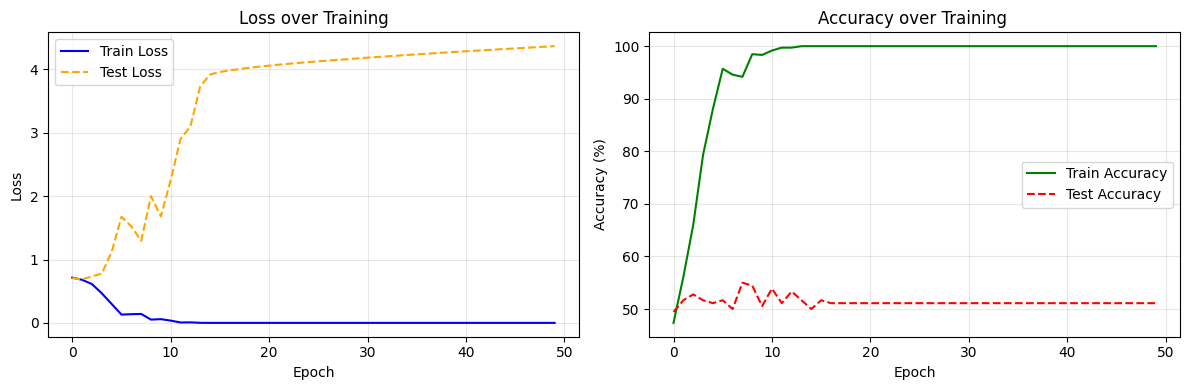


─── Final Results ───────────────────────────
Final train accuracy: 100.0%
Final test accuracy:  51.1%
Best test accuracy:   55.0%


In [44]:
import matplotlib.pyplot as plt

# set up side by side canvas
# creates 1 row with 2 columns of subplot axes (ax1 for loss, ax2 for accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

# plot loss curves (left)
ax1.plot(train_losses, label = "Train Loss", color = "blue", linestyle = "-")
ax1.plot(test_losses, label = "Test Loss", color = "orange", linestyle = "--")
ax1.set_title("Loss over Training")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha = 0.3)


# plot accuracy curves (right)
ax2.plot(train_accuracies, label = "Train Accuracy", color = "green", linestyle = "-")
ax2.plot(test_accuracies, label = "Test Accuracy", color = "red", linestyle = "--")
ax2.set_title("Accuracy over Training ")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.savefig(
    f"{ARTIFACT_DIR}/training_curves.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

print(f"\n─── Final Results ───────────────────────────")
# [-1] fetches the final metric recorded at the 50th epoch
print(f"Final train accuracy: {train_accuracies[-1]:.1f}%")
print(f"Final test accuracy:  {test_accuracies[-1]:.1f}%")
print(f"Best test accuracy:   {best_test_accuracy:.1f}%")

In [45]:

import json




# save model config
# we save these settings separately so we can
# rebuild the exact same model architecture later
# when loading it in FastAPI for serving
model_config ={
    "in_channels": 64,
    "conv_out": 32,
    "d_model": 96,
    "nhead": 4,
    "num_layers": 2,
    "num_classes": 2
}


with open(f"{ARTIFACT_DIR}/model_config.json", "w") as f:
  json.dump(model_config, f, indent = 4)

print("Model config saved")


Model config saved


In [46]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

all_predictions = []
all_labels =[]

with torch.no_grad():
  for batch_X, batch_y in test_loader:

    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    outputs = model(batch_X)

    predictions = outputs.argmax(dim = 1)

    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(batch_y.cpu().numpy())



all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions collected!")

Predictions collected!


In [47]:
precision  = precision_score(all_labels, all_predictions)
recall     = recall_score(all_labels, all_predictions)
f1         = f1_score(all_labels, all_predictions)


print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

report = classification_report(
    all_labels,
    all_predictions,
    target_names = ["Left Fist", "Right Fist"]
)

print("\nClassification Report!\n")
print(report)

Precision: 0.5067
Recall:    0.4270
F1 Score:  0.4634

Classification Report!

              precision    recall  f1-score   support

   Left Fist       0.51      0.59      0.55        91
  Right Fist       0.51      0.43      0.46        89

    accuracy                           0.51       180
   macro avg       0.51      0.51      0.51       180
weighted avg       0.51      0.51      0.51       180



In [13]:



import json
# shutil = copy files between folders
import shutil
import os
import subprocess

# datetime = get current date/time for commit messages
from datetime import datetime
from google.colab import userdata


GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
GITHUB_USERNAME = "the-liyanage"
REPO_NAME = "neurosynth"


# 1. set git identity
subprocess.run(["git", "config", "--global",
               "user.name", "the-liyanage"])

subprocess.run(["git", "config", "--global",
                "user.email", "hiruniliyanage4@gmail.com"])


# 2. Clone repo fresh (only if not already there)
if not os.path.exists(f"/content/{REPO_NAME}/.git"):
  subprocess.run(["rm", "-rf", "f/content/{REPO_NAME}"])
  os.chdir("/content")
  subprocess.run([
      "git", "clone",
      f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
      ])
  print("Repo clones fresh!")
else:
  print("Repo already exisit, skipping clone")




# 3. Copy notebook into repo
os.makedirs(f"/content/{REPO_NAME}/notebooks", exist_ok = True)
shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/03_model_training.ipynb",
    f"/content/neurosynth/notebooks/03_model_training.ipynb"
)
print(f"\n Notebook copied!")


# 4. Commit and push

# move into the repo folder
os.chdir(f"/content/{REPO_NAME}")

# stage all change
subprocess.run(["git", "pull"])
subprocess.run(["git", "add", "."])


commit_message = "subject split properly(data leakage issue)"

subprocess.run(["git", "commit", "-m", commit_message])


result = subprocess.run([
    "git", "push",
    f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git",
    "main"
], capture_output=True, text=True)


if result.returncode == 0:
  print("Pushed to the github", commit_message)
else:
  print("Push failed")
  print(result.stderr)

Repo clones fresh!

 Notebook copied!
Pushed to the github subject split properly(data leakage issue)
